In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Загрузка данных
df_full = pd.read_parquet('../data/processed/gbpusd_15m.parquet')
# Берем последние 50,000 свечей для настройки алгоритма
df = df_full.tail(50000).copy()

print(f"✅ Данные загружены. Исследуем {len(df)} свечей.")

✅ Данные загружены. Исследуем 50000 свечей.


In [2]:
# Рассчитываем ATR
prev_close = df['close'].shift(1)
tr = pd.concat([df['high'] - df['low'], (df['high'] - prev_close).abs(), (df['low'] - prev_close).abs()], axis=1).max(axis=1)
df['atr_14'] = tr.rolling(14).mean()

# Собираем фичи
features = pd.DataFrame({
    'atr_14': df['atr_14'],
    'momentum_abs': (df['close'] / df['close'].shift(16) - 1).abs(),
    'volatility': np.log(df['close'] / prev_close).rolling(14).std()
}).bfill().fillna(0)

# Масштабируем
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("✅ Фичи подготовлены и отмасштабированы!")

✅ Фичи подготовлены и отмасштабированы!


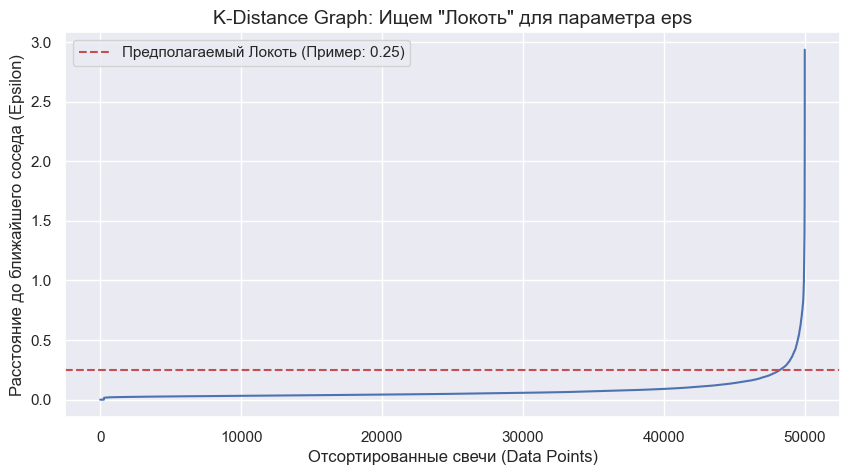

ВОПРОС К ВАМ: На каком значении по оси Y синяя линия начинает резко изгибаться вверх (улетать в космос)?


In [3]:
# Ищем расстояние до 5 ближайших соседей (min_samples обычно берут = удвоенному кол-ву фичей, у нас их 3)
min_samples = 6 
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Сортируем расстояния и рисуем график
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Graph: Ищем "Локоть" для параметра eps', fontsize=14)
plt.xlabel('Отсортированные свечи (Data Points)')
plt.ylabel('Расстояние до ближайшего соседа (Epsilon)')
plt.axhline(y=0.25, color='r', linestyle='--', label='Предполагаемый Локоть (Пример: 0.25)')
plt.legend()
plt.show()

print("ВОПРОС К ВАМ: На каком значении по оси Y синяя линия начинает резко изгибаться вверх (улетать в космос)?")

In [4]:
# ВНИМАНИЕ: Замените 0.25 на значение "локтя" из Ячейки 3
optimal_eps = 0.25 

print(f"Запускаем DBSCAN (eps={optimal_eps}, min_samples={min_samples})...")
dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Анализ кластеров
cluster_counts = df['dbscan_cluster'].value_counts()
print("\n📊 Результаты кластеризации:")
print(cluster_counts)

# Вычисляем среднюю волатильность для каждого "нормального" кластера (исключая -1)
normal_clusters = df[df['dbscan_cluster'] != -1]
cluster_stats = normal_clusters.groupby('dbscan_cluster')['atr_14'].mean().sort_values()

print("\n📈 Средний ATR по нормальным кластерам:")
print(cluster_stats)

print("\n⚠️ Кластер '-1' — это ВСТРОЕННЫЙ KILL SWITCH. Это свечи, которые не похожи ни на что другое (Аномалии).")

Запускаем DBSCAN (eps=0.25, min_samples=6)...

📊 Результаты кластеризации:
dbscan_cluster
 0     48476
-1      1249
 7        20
 4        19
 11       19
 12       18
 15       13
 3        12
 27       12
 19       10
 16       10
 1         9
 23        9
 13        9
 18        9
 8         8
 21        7
 9         7
 30        7
 17        7
 24        7
 5         6
 6         6
 25        6
 26        6
 14        6
 29        6
 20        6
 22        6
 28        6
 10        5
 2         4
Name: count, dtype: int64

📈 Средний ATR по нормальным кластерам:
dbscan_cluster
15    0.000616
0     0.000736
24    0.000945
6     0.001062
22    0.001087
2     0.001101
9     0.001165
13    0.001191
20    0.001267
19    0.001268
14    0.001335
7     0.001488
25    0.001596
26    0.001610
1     0.001664
18    0.001713
27    0.001794
10    0.001796
11    0.001862
4     0.001905
16    0.001920
29    0.001972
12    0.001978
3     0.001995
8     0.001995
30    0.001997
17    0.002000
21    0.

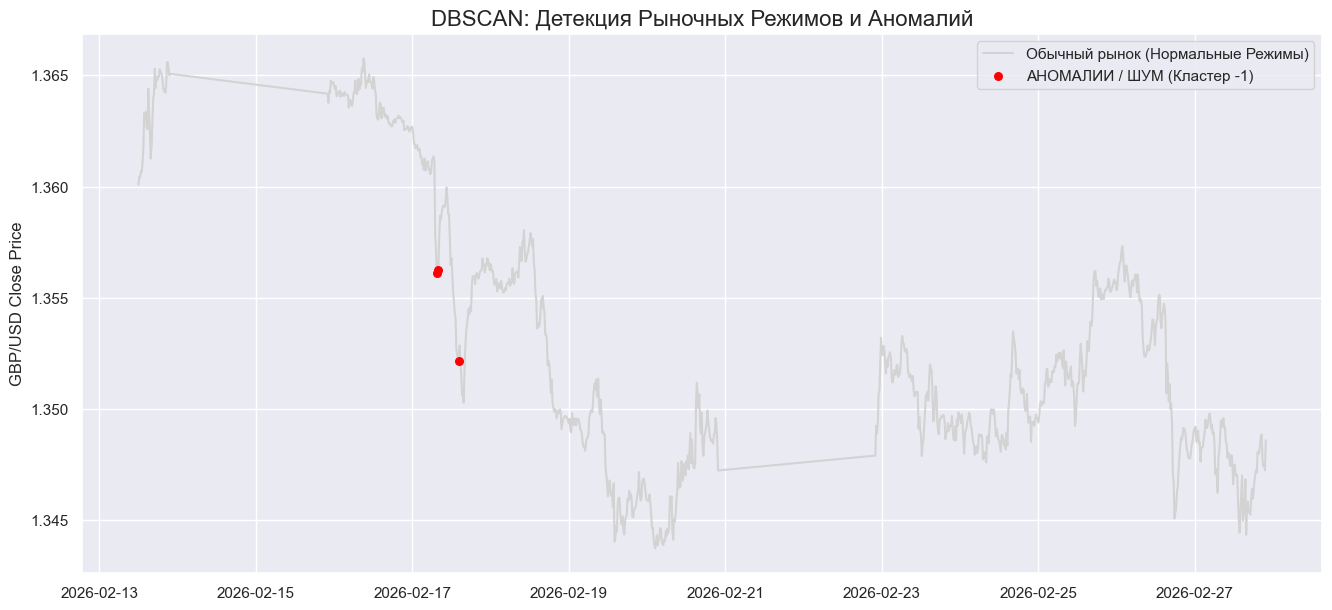

In [5]:
# Берем кусок в 1000 свечей, чтобы было видно
plot_df = df.tail(1000).copy()

plt.figure(figsize=(16, 7))

# 1. Рисуем "нормальные" кластеры серым цветом (Фон)
plt.plot(plot_df.index, plot_df['close'], color='lightgray', label='Обычный рынок (Нормальные Режимы)', linewidth=1.5)

# 2. Выделяем АНОМАЛИИ (Кластер -1) красными точками
anomalies = plot_df[plot_df['dbscan_cluster'] == -1]
plt.scatter(anomalies.index, anomalies['close'], color='red', label='АНОМАЛИИ / ШУМ (Кластер -1)', zorder=5, s=30)

plt.title('DBSCAN: Детекция Рыночных Режимов и Аномалий', fontsize=16)
plt.ylabel('GBP/USD Close Price')
plt.legend()
plt.show()